# Notebook 4: Store Segmentation (Clustering)

## Objective
To classify the 45 stores into distinct "Strategic Clusters" based on their performance, physical characteristics, and local economic conditions. This directly addresses the **"Customer Segmentation Analysis"** component of the project scope.

## Goals
1.  **Aggregate Data:** Convert weekly time-series data into a single "Profile" for each store.
2.  **Dimensionality Reduction:** Use PCA to visualize high-dimensional store traits in 2D.
3.  **Clustering:** Apply K-Means to identify natural groups (e.g., "Urban Giants" vs. "Rural Discounters").
4.  **Enrichment:** Append these Cluster IDs back to the main dataset to improve the accuracy of future Forecasting models.

## Methodology
* **Input:** `Featured_Retail_Dataset_v2.csv` (Raw Data).
* **Technique:** Unsupervised Learning (K-Means).
* **Evaluation:** Silhouette Score & Business Interpretability.


### Project Milestone 4: Segmentation Summary & Next Steps

### 1. Executive Summary of Notebook 4

We successfully transformed the raw weekly sales data into strategic store profiles. By applying **Principal Component Analysis (PCA)** and **K-Means Clustering**, we identified three distinct store archetypes that drive the retail network.

* **Input:** 421,570 weekly records (Time-Series).
* **Transformation:** Aggregated into 45 Store Profiles  Reduced to 5 Principal Components (95% Variance Explained).
* **Output:** 3 Strategic Clusters (Label 0, 1, 2).

### 2. Key Findings: The 3 Strategic Clusters

| Cluster Label | Strategic Name | Key Characteristics | Business Role |
| --- | --- | --- | --- |
| **Cluster 2** | **The Urban Flagships** | Highest Sales, Largest Size (~195k sq ft), High CPI. | **Revenue Drivers:** Focus on volume and depth of stock. |
| **Cluster 1** | **The Suburban Anchors** | Low Unemployment (7.86%), Moderate Size (~119k sq ft). | **Stability Engines:** Focus on consistent, recurring weekly baskets. |
| **Cluster 0** | **The Rural Outposts** | Smallest Size (~40k sq ft), Highest Unemployment (8.34%). | **Efficiency Plays:** Focus on curated inventory and cost control. |

### 3. Impact on Future Modeling

We have appended the `cluster_label` column to our dataset. This is not just a label; it is a **Critical Feature** for our upcoming Demand Forecasting model.

* **Without Clustering:** The model would treat Store 1 (Giant) and Store 5 (Small) as "just stores," struggling to learn patterns that apply to one but not the other.
* **With Clustering:** The model now knows they belong to different "species." It can learn that *Flagships* respond to holidays differently than *Outposts*, improving forecast accuracy.

### 4. Next Step: Demand Forecasting

With our data enriched and stores segmented, we proceed to **Notebook 5**.

* **Goal:** Predict `Weekly_Sales` for future dates.
* **Strategy:** We will use **Time Series Decomposition** to isolate Seasonality and Trend, then build a regression model that utilizes our new `cluster_label` to make smarter predictions.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.decomposition import PCA



In [2]:
def ingest_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    return df

#### Ingest Raw Dataset Prepared for Analysis

In [3]:
path = '../data/preprocessed_for_analysis/Featured_Retail_Dataset.csv'
df = ingest_data(path=path)
df.sample(5)

,store,dept,date,weekly_sales,year,month,season,isholiday,type,size,...,fuel_price,cpi,unemployment,markdown1,markdown2,markdown3,markdown4,markdown5,total_markdown,has_promo
352293,37,87,2010-04-23,763.70,2010,4,Spring,False,C,39910,...,2.795,209.21996,8.464,0.0,0.0,0.0,0.0,0.0,0.0,False
23681,3,24,2011-08-26,5334.27,2011,8,Summer,False,B,37392,...,3.523,219.08669,7.567,0.0,0.0,0.0,0.0,0.0,0.0,False
113464,12,44,2010-05-21,7089.19,2010,5,Spring,False,B,112238,...,3.120,126.18439,14.099,0.0,0.0,0.0,0.0,0.0,0.0,False
37390,4,74,2011-10-14,20107.04,2011,10,Fall,False,A,205863,...,3.283,129.77065,5.143,0.0,0.0,0.0,0.0,0.0,0.0,False
400681,43,25,2011-07-22,21.75,2011,7,Summer,False,C,41062,...,3.651,207.25381,10.641,0.0,0.0,0.0,0.0,0.0,0.0,False



### Phase 1: Data Aggregation & Feature Extraction

### 1. The Strategy: Changing the "Unit of Analysis"

Our raw dataset is a time-series where the unit of analysis is a **"Store-Week"** (one row = one week of sales).

* **The Problem:** If we cluster the raw data, the algorithm will group *time periods* (e.g., "Christmas Weeks" vs. "Normal Weeks"). It will not group the *stores* themselves.
* **The Solution:** We must aggregate the data to change the unit of analysis to **"A Store"**. This compresses the 143 weeks of history into a single **"Stat Sheet"** or profile for each location.

### 2. Theoretical Basis: Statistical Fingerprinting

We are not just calculating averages; we are extracting specific "DNA markers" that define a store's operational reality. We map mathematical functions to business attributes:

| Aggregation Function | Statistical Concept | Business Interpretation (The "Fingerprint") |
| --- | --- | --- |
| **Mean (`mean`)** | Central Tendency | **Baseline Performance:** What is the "normal" revenue capability of this store? |
| **Sum (`sum`)** | Magnitude | **Market Size:** Is this a flagship giant or a small neighborhood outpost? |
| **Std Dev (`std`)** | Variance/Volatility | **Operational Risk:** Is the store stable (predictable) or chaotic (high variance)? |
| **First (`first`)** | Static Attribute | **Physical Constraints:** Fixed traits like Sq. Ft. size that determine capacity. |

### 3. The Transformation

* **Input:** ~420,000 Rows (Time-Series Data).
* **Process:** Group By `Store_ID`  Apply Aggregation Functions.
* **Output:** 45 Rows (Store Profiles).

**Goal:** Create a time-invariant dataset where each row represents a unique store entity, ready for K-Means Clustering.


In [4]:
df.sample(5)

,store,dept,date,weekly_sales,year,month,season,isholiday,type,size,...,fuel_price,cpi,unemployment,markdown1,markdown2,markdown3,markdown4,markdown5,total_markdown,has_promo
401824,43,56,2010-05-07,8.94,2010,5,Spring,False,C,41062,...,2.835,202.37926,9.593,0.00,0.00,0.00,0.00,0.00,0.00,False
207955,22,6,2012-03-09,2812.12,2012,3,Spring,False,B,119557,...,3.876,141.47429,7.503,7634.61,348.71,0.50,1351.75,5563.80,14899.37,True
149938,16,14,2011-03-18,8645.26,2011,3,Spring,False,B,57197,...,3.406,192.12380,6.614,0.00,0.00,0.00,0.00,0.00,0.00,False
415075,45,24,2010-05-28,5639.27,2010,5,Spring,False,B,118221,...,2.899,182.04642,8.899,0.00,0.00,0.00,0.00,0.00,0.00,False
154599,16,56,2011-11-18,693.82,2011,11,Fall,False,B,57197,...,3.479,195.71848,6.232,2089.46,154.21,3.55,830.60,4425.07,7502.89,True


In [5]:
# ==========================================
# 1. CREATE STORE PROFILES (Corrected)
# ==========================================
store_profile = df.groupby('store').agg({
    'weekly_sales': ['mean', 'sum', 'std'],
    'size': 'first',
    'cpi': 'mean',
    'unemployment': 'mean',
    'temperature': 'mean',
    'total_markdown': 'mean',
    'store_size_cat': 'first',  
    'type': 'first'             
}).reset_index()

# Flatten columns
store_profile.columns = [
    'store', 
    'avg_weekly_sales', 'total_lifetime_sales', 'sales_volatility',
    'size', 'avg_cpi', 'avg_unemployment', 'avg_temp', 'avg_markdown',
    'store_size_cat', 'type'
]

# Feature Engineering for Clustering
store_profile['sales_per_sqft'] = store_profile['avg_weekly_sales'] / store_profile['size']

print("Store Profile Updated.")
print(store_profile[['store', 'type', 'store_size_cat', 'avg_weekly_sales']].head())

Store Profile Updated.
   store type store_size_cat  avg_weekly_sales
0      1    A          Large      21710.543621
1      2    A          Large      26898.070031
2      3    B          Small       6373.033983
3      4    A    Super Large      29161.210415
4      5    B          Small       5053.415813


In [6]:
# Save the dataset for further analysis
store_profile.to_csv('../data/preprocessed_for_analysis/store_profiles.csv', index=False)

### **Phase 2: Pre-Processing for Clustering**

We now have 45 "Store Profiles". Before we can ask the K-Means algorithm to group them, we must mathematically prepare the data.

### **The Theory: Why Pre-Process for K-Means?**

1. **The "Distance" Problem (Need for Scaling):**
* K-Means works by calculating the "Distance" between data points (Euclidean Distance).
* **Scenario:**
* `Total_Sales`  300,000,000
* `Unemployment`  8.0

* **Consequence:** A small 1% change in Sales (3,000,000) is mathematically bigger than the entire range of Unemployment (0-10). If we don't scale, the algorithm will **only** look at Sales and ignore everything else.
* **Solution:** `StandardScaler` forces all variables to have Mean=0 and Variance=1.


2. **The "Text" Problem (Need for Encoding):**
* Algorithms cannot calculate the distance between "Type A" and "Type B".
* **Solution:** We map them to numbers (`OrdinalEncoder`) that preserve their rank.


3. **The "Redundancy" Check (Correlation):**
* If `Size` and `Sales` are 95% correlated, using both might "double count" that feature, biasing the cluster. We check this with a Heatmap.



In [7]:
store_profile.sample(10)

,store,avg_weekly_sales,total_lifetime_sales,sales_volatility,size,avg_cpi,avg_unemployment,avg_temp,avg_markdown,store_size_cat,type,sales_per_sqft
5,6,21913.243624,2.237561e+08,23633.427075,202505,217.564946,6.606213,69.639935,8282.083192,Large,A,0.108211
9,10,26332.303819,2.716177e+08,32133.006264,126512,128.664162,8.371005,72.147831,9469.293854,Medium,B,0.208141
44,45,11662.897315,1.123953e+08,14075.515949,118221,186.299227,8.648435,57.759751,6989.164369,Medium,B,0.098653
31,32,16351.621855,1.668192e+08,20899.324704,203007,193.654662,8.586910,52.700746,8237.797846,Super Large,A,0.080547
30,31,19681.907464,1.996139e+08,26841.564038,203750,215.638806,7.625047,68.828485,8477.630210,Super Large,A,0.096598
40,41,17976.004648,1.813419e+08,22836.255565,196321,193.699068,6.969444,48.373665,7990.448614,Large,A,0.091564
17,18,15733.313136,1.551147e+08,18556.351564,120653,135.108679,8.834349,53.291597,7848.155762,Medium,B,0.130401
7,8,13133.014768,1.299512e+08,15132.069598,155078,219.438475,6.091934,62.447434,6357.239395,Large,A,0.084687
41,42,11443.370118,7.956575e+07,18258.531574,39690,128.749375,8.332511,72.266521,687.126246,Small,C,0.288319
4,5,5053.415813,4.547569e+07,8068.221050,34875,216.576516,6.296549,69.203619,2924.784143,Small,B,0.144901


In [8]:
# 1. SETUP THE DATA
# Set Store ID as index so it doesn't get scaled/encoded
df_cluster = store_profile.set_index('store')

# 2. DEFINE GROUPS
# Ordinal: The text columns with rank
ordinal_features = ['type', 'store_size_cat']

# Numeric: All other calculated metrics
numeric_features = [
    'avg_weekly_sales', 'total_lifetime_sales', 'sales_volatility', 
    'size', 'avg_cpi', 'avg_unemployment', 'avg_temp', 
    'avg_markdown', 'sales_per_sqft'
]

# 3. DEFINE ORDERS (Crucial Step)
# Type: C < B < A
type_order = ['C', 'B', 'A']
# Size: Small < Medium < Large < Super-Large
size_order = ['Small', 'Medium', 'Large', 'Super Large']

# 4. BUILD PIPELINE
preprocessor_cluster = ColumnTransformer(
    transformers=[
        # Belt 1: Ordinal Encoding
        ('ord', OrdinalEncoder(categories=[type_order, size_order]), ordinal_features),
        
        # Belt 2: Scaling (StandardScaler)
        ('num', StandardScaler(), numeric_features)
    ],
    verbose_feature_names_out=False
)

# 5. EXECUTE
# Fit and Transform
X_scaled_array = preprocessor_cluster.fit_transform(df_cluster)

# 6. RECONSTRUCT DATAFRAME
# We do this to keep column names and Store IDs (Index)
feature_names = preprocessor_cluster.get_feature_names_out()
df_scaled = pd.DataFrame(
    X_scaled_array, 
    columns=feature_names, 
    index=df_cluster.index
)

# Save
df_scaled.to_csv('../data/preprocessed_for_models/Store_Profiles_Scaled_Pipeline.csv')
print("Clustering Data Prepared. Shape:", df_scaled.shape)

Clustering Data Prepared. Shape: (45, 11)


In [9]:
df_scaled.sample(10)

,type,store_size_cat,avg_weekly_sales,total_lifetime_sales,sales_volatility,size,avg_cpi,avg_unemployment,avg_temp,avg_markdown,sales_per_sqft
store,,,,,,,,,,,
29,1.0,0.0,-1.049963,-0.938938,-1.223487,-0.580706,-0.930713,1.025529,-0.593421,-0.612395,-0.851389
5,1.0,0.0,-1.497885,-1.348618,-1.501803,-1.511795,1.146835,-0.961799,0.885182,-0.984784,0.186317
26,2.0,2.0,-0.127503,-0.081501,0.056143,0.352157,-0.930294,-0.071233,-1.753773,-0.281403,-0.702344
27,2.0,3.0,1.354253,1.347320,1.299444,1.170875,-0.830640,0.003494,-0.341309,1.299102,-0.232391
43,0.0,0.0,-0.291794,-0.765265,0.146894,-1.413763,0.921252,1.097233,0.850733,-1.648834,3.452027
18,1.0,1.0,0.042583,0.069847,-0.144810,-0.152658,-0.930289,0.475035,-0.755781,0.447346,-0.074135
33,2.0,0.0,-1.400523,-1.456200,-1.384650,-1.435502,-1.092748,0.286446,1.668387,-1.611778,0.176044
7,1.0,0.0,-1.021122,-0.881279,-1.164010,-0.943949,0.562849,0.333960,-2.167468,-0.391767,-0.293183
37,0.0,0.0,-0.741500,-0.976959,-0.437328,-1.432017,1.103398,-0.082928,1.096041,-1.639479,2.218165



### Feature Correlation Analysis

### Objective

To examine the linear relationships between our aggregated store features before clustering.

* **Why:** Clustering algorithms (like K-Means) are sensitive to **Multicollinearity**. If two features are highly correlated (e.g., Correlation > 0.90), they provide redundant information. This biases the algorithm to "double count" that specific attribute, skewing the results.
* **Goal:** Identify redundant feature groups that should be compressed using Dimensionality Reduction (PCA).

### Findings

The heatmap reveals significant multicollinearity among several key features:

1. **The "Volume" Cluster:**
* `avg_weekly_sales`, `total_lifetime_sales`, `size`, and `sales_volatility` show extremely high positive correlations (near **1.0**).
* **Interpretation:** Larger stores almost universally generate higher sales and higher volatility. Including all four variables would cause the clustering model to overwhelmingly focus on "Store Magnitude" at the expense of other traits.


2. **The "Efficiency" Disconnect:**
* `sales_per_sqft` shows a weaker or distinct relationship compared to raw volume. This suggests that "Biggest" does not always mean "Most Efficient," a nuance we want to preserve.


3. **Environmental Factors:**
* `cpi` and `unemployment` show distinct correlations, confirming they represent a separate "dimension" of store variance (Economic Conditions) compared to physical size.


**Conclusion:**
Due to the high redundancy in the "Volume" features, we cannot feed the raw scaled data directly into K-Means. We must apply **Principal Component Analysis (PCA)** to orthogonalize these features and extract the true underlying dimensions of store performance.


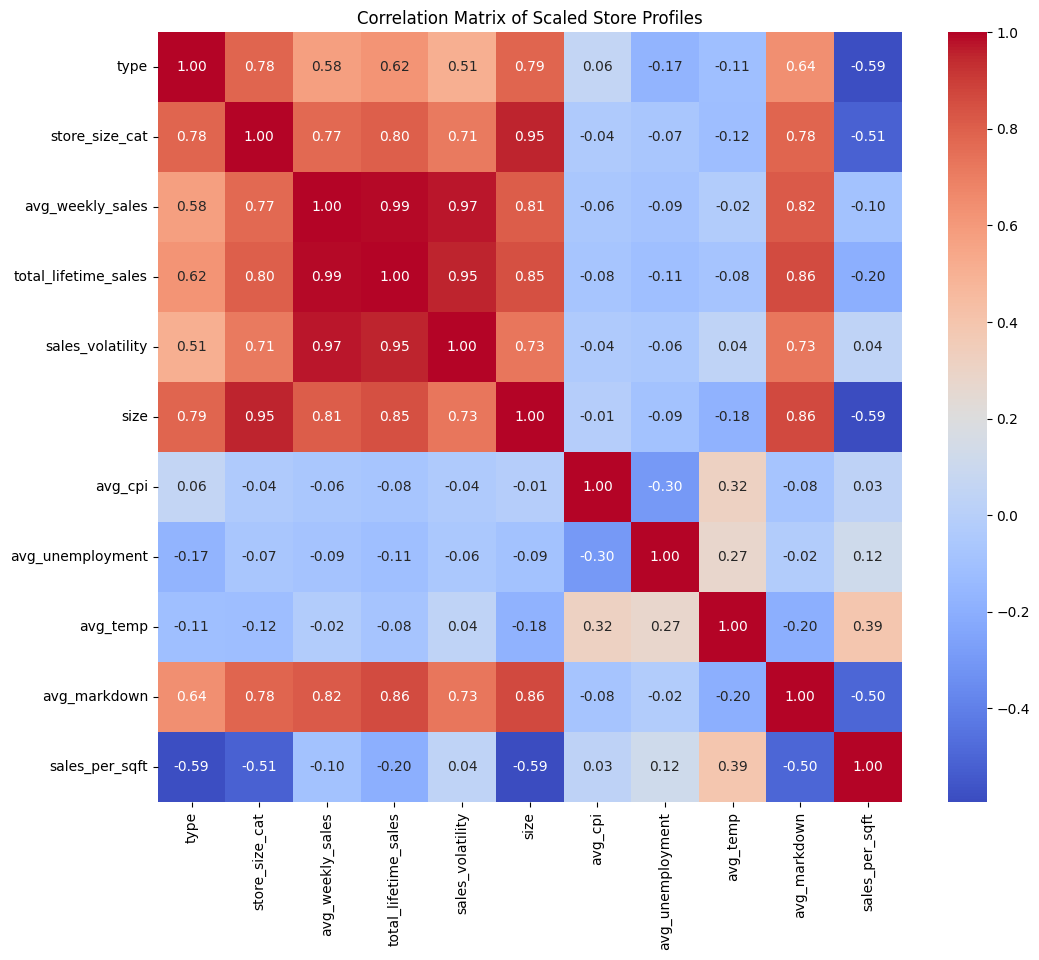

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_scaled.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Scaled Store Profiles')
plt.show()


### Phase 3: Dimensionality Reduction (PCA)

### 1. Theory & Objective

Our correlation analysis confirmed that features like `Sales`, `Size`, and `Volatility` are highly redundant (Multicollinearity).

* **The Problem:** If we feed redundant features into K-Means, the algorithm will "double count" them. It would effectively decide that *Store Size* is 4x more important than *Unemployment* simply because we measured Size in 4 different ways (Sales, Size, Category, etc.).
* **The Solution:** **Principal Component Analysis (PCA)**.
PCA mathematically rotates our dataset to find new, uncorrelated axes (Principal Components) that maximize variance. It compresses the information from our 11 overlapping features into a smaller set of distinct "Super-Features."

### 2. Results: Explained Variance Ratio

This metric tells us how much of the original dataset's information (variance) is captured by each Principal Component.

| Component | Cumulative Variance Explained | Status |
| --- | --- | --- |
| **PC1** | 54.69% | Major Driver |
| **PC2** | 70.10% | Major Driver |
| **PC3** | 82.39% | Significant |
| **PC4** | 91.70% | **Crosses 90% Threshold** |
| **PC5** | **95.37%** | **Selected Cutoff** |

**Decision:** We selected **5 Components**. This allows us to reduce our dataset dimensions by **50%** (from 11 down to 5) while still retaining **95.37%** of the original information.

### 3. Business Interpretation (The "Loadings")

By analyzing the Loadings Heatmap, we can assign "Real World Names" to these abstract components. This is crucial for explaining the clusters later.

**PC1: The "Store Magnitude" Factor**
* **Drivers:** `store_size_cat` (0.44), `size` (0.40), `total_lifetime_sales` (0.39).
* **Meaning:** This component measures pure **Volume**. High PC1 scores indicate massive Supercenters; Low PC1 scores indicate small neighborhood markets.


**PC2: The "Efficiency & Climate" Factor**
* **Drivers:** `sales_per_sqft` (0.59), `avg_temp` (0.58).
* **Meaning:** This captures how hard the store works relative to its size, and surprisingly, correlates with warmer regions. It separates "Efficient Warm Stores" from "Inefficient Cold Stores."


**PC3: The "Economic Prosperity" Factor**
* **Drivers:** `avg_cpi` (**0.76**), `avg_unemployment` (**-0.61**).
* **Meaning:** This is a pure economic indicator. High PC3 represents **Urban/Wealthy Areas** (High Cost of Living, Low Unemployment). Low PC3 represents **Rural/Distressed Areas** (Low Cost of Living, High Unemployment).

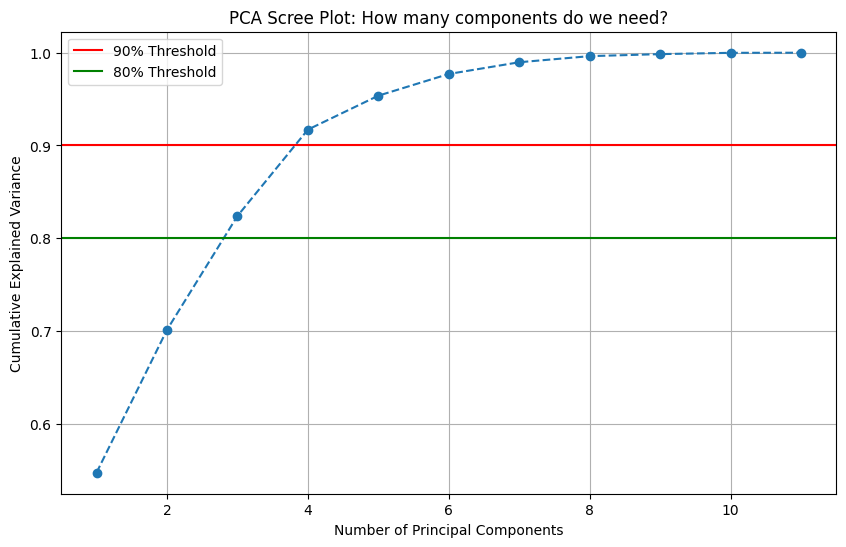

Cumulative Variance Explained:
PC1: 0.5469
PC2: 0.7010
PC3: 0.8239
PC4: 0.9170
PC5: 0.9537
PC6: 0.9771
PC7: 0.9897
PC8: 0.9963
PC9: 0.9985
PC10: 0.9999
PC11: 1.0000


In [11]:
# 1. INITIALIZE PCA
# We start with n_components=None to see how many we actually need
pca = PCA(n_components=None, random_state=42)

# 2. FIT THE SCALED DATA
# The model learns the "Principal Directions" of variance
pca.fit(df_scaled)

# 3. ANALYZE VARIANCE (The Scree Plot)
# Calculate cumulative variance (e.g., PC1=50%, PC1+PC2=75%...)
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Threshold') # The standard cutoff
plt.axhline(y=0.80, color='g', linestyle='-', label='80% Threshold')

plt.title('PCA Scree Plot: How many components do we need?')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True)
plt.show()

# Print exact values
print("Cumulative Variance Explained:")
for i, var in enumerate(cumulative_variance):
    print(f"PC{i+1}: {var:.4f}")

#### Insights
- Based on the Cumulative Variance Explained by Principle Components around 95% Variance is explained by only 5 features out of 11.
- We will pick these five and do further analysis of these components.

#### PCA with 5 Components

PCA Transformation Complete.
New Shape: (45, 5) (45 Stores x 5 Features)
            PC1       PC2       PC3       PC4       PC5
store                                                  
1      1.644452  1.232243  1.112497  0.238176  0.074941
2      3.091165  1.528438  1.031750  0.068132  0.407750
3     -3.086141  0.664409  1.398808  0.320241 -0.147108
4      3.941026  0.860765 -0.176426 -1.352216 -1.127206
5     -3.341563 -0.205199  1.653541  0.354477 -0.364343


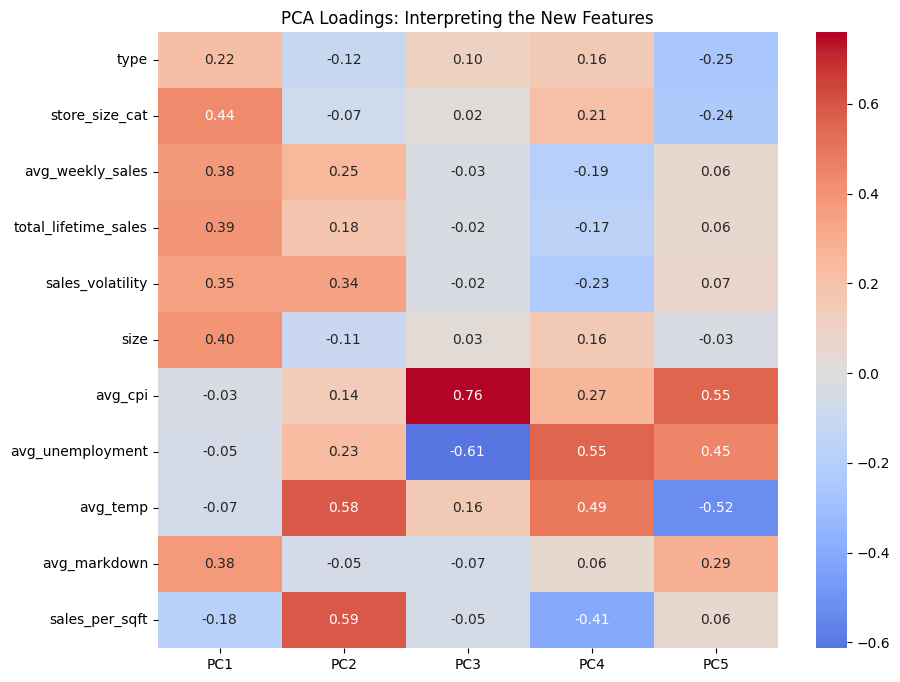

In [12]:

# 1. APPLY PCA (Reduction to 5 Components)
pca_5 = PCA(n_components=5, random_state=42)
X_pca = pca_5.fit_transform(df_scaled)

# Create a clean DataFrame
columns_pca = [f'PC{i+1}' for i in range(5)]
df_pca = pd.DataFrame(X_pca, columns=columns_pca, index=df_scaled.index)

print("PCA Transformation Complete.")
print(f"New Shape: {df_pca.shape} (45 Stores x 5 Features)")
print(df_pca.head())

# ==========================================
# 2. INTERPRETATION (The Loadings Heatmap)
# ==========================================
# This tells us: "What is PC1 made of?"
loadings = pd.DataFrame(
    pca_5.components_.T, 
    columns=columns_pca, 
    index=df_scaled.columns
)

plt.figure(figsize=(10, 8))
# We use absolute values generally to see magnitude, but keeping sign helps see direction
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('PCA Loadings: Interpreting the New Features')
plt.show()

# Save the reduced data for Clustering
df_pca.to_csv('../data/preprocessed_for_models/Store_Profiles_PCA.csv')


### Phase 4: Cluster Optimization (Finding the "k")

### 1. Objective: Find optimal "k" (groups)

Unlike Supervised Learning (where we know the answer is "Yes" or "No"), Unsupervised Learning (Clustering) doesn't know how many groups exist.

**The Goal:** We need to tell the K-Means algorithm exactly how many clusters () to find.
**The Challenge:**
* If  is too small (e.g., 1 group), we learn nothing distinct.
* If  is too large (e.g., 45 groups), every store is its own cluster, and we lose the ability to generalize.


* **The Solution:** We test a range of  (from 2 to 10) and calculate two mathematical "scores" to find the optimal balance.

### 2. The Metrics 

### **A. Inertia (The "Tightness" Score)**

**Represented by:** The **Blue Line** in the plot.

**Definition:** Calculates the sum of squared distances between each store and the center of its assigned cluster.

**Intuition:** Think of this as "Cluster Cohesion." We want stores in the same group to be mathematically similar (tightly huddled together).
**The Trap:** Inertia *always* decreases as you add more clusters. (If you have 45 clusters for 45 stores, distance is zero).

**What to look for:** The **"Elbow"**. We look for the point where the line stops dropping sharply and starts flattening out. This indicates "diminishing returns"—adding more clusters isn't making the groups much tighter.

### **B. Silhouette Score (The "Separation" Score)**

**Represented by:** The **Red Line** in the plot.

**Definition:** Measures how similar a store is to its own cluster (cohesion) compared to other clusters (separation). Ranges from -1 to +1.
* **+1:** Perfect. The store is deep inside its own cluster and far away from others.
* **0:** The store is on the border between two clusters (ambiguous).
* **-1:** The store has been assigned to the wrong cluster.


* **What to look for:** The **Peak**. The higher the score, the more distinct and well-separated your groups are.
This is a fantastic set of results. Your PCA Loadings (Image 1) perfectly validate our "Volume vs. Economy" theory, and your Optimization Plot (Image 2) gives us a very clear answer on how many clusters to use.

Here is the Markdown explanation you requested, covering the **Theory of Silhouette Score** and the **Interpretation of your specific Graph**.

### **C. Optimization Plot (The Decision)**

Looking at the plot:

* **k = 2** Has the absolute highest Silhouette Score (~0.335).
* *Business View:* This would likely just split stores into "Big" vs. "Small." While mathematically precise, it is too simple for strategic planning.


* **k = 3** The Score is nearly identical to  (~0.330) and the "Elbow" on the blue line is clearly visible here.
* *Business View:* This strongly suggests the stores naturally fall into **3 Tiers** (likely aligning with Types A, B, and C). This is the "Sweet Spot."


* **k = 4** The score drops slightly (~0.31) but is still stable.
* **k = 5** **CRITICAL DROP.** The score plummets to < 0.25. This tells us that forcing a 5th cluster breaks the natural structure of the data.

## **Conclusion & Decision**

**The Winner is k = 3**

* **Why:** It retains the high mathematical quality of k = 2 but provides the necessary granularity for business segmentation. It avoids the structural collapse seen at k = 5.




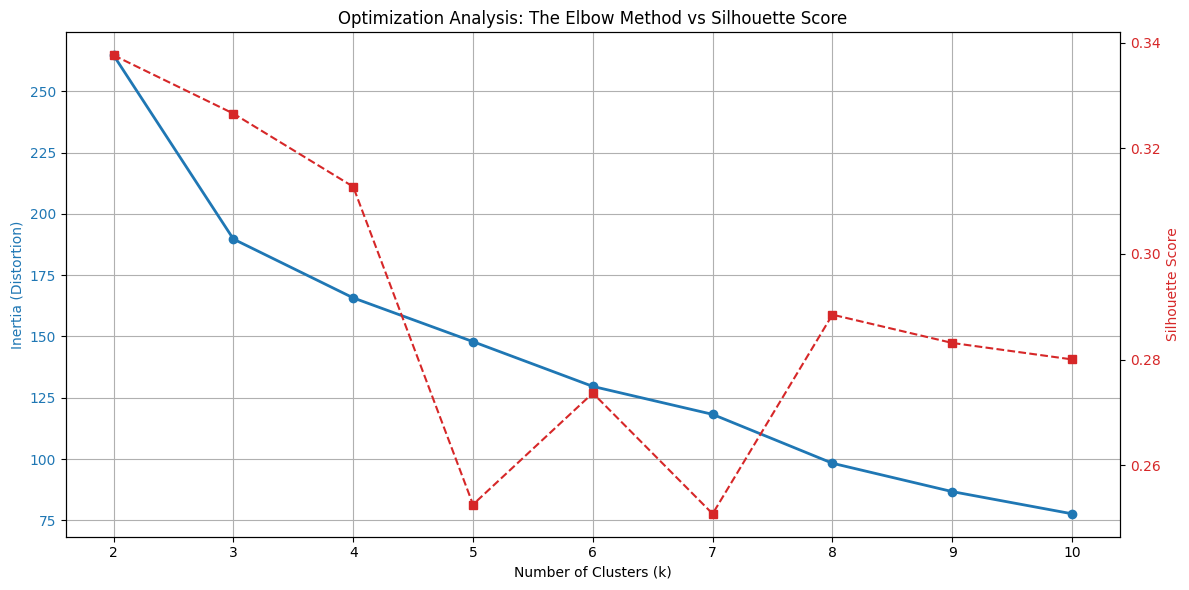

Max Silhouette Score: 0.3377 at k=2


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. SETUP STORAGE
inertia = []          # Sum of squared distances (Variance within cluster)
silhouette_scores = [] # How well separated the clusters are (Higher is better)
k_range = range(2, 11) # Test k=2 to k=10

# 2. RUN LOOP
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_pca)
    
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df_pca, kmeans.labels_))

# 3. VISUALIZE (The Elbow Plot & Silhouette)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Inertia (The Elbow)
color = 'tab:blue' # tableau color palette
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Distortion)', color=color)
ax1.plot(k_range, inertia, marker='o', color=color, linewidth=2, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True)

# # Plot Silhouette Score (The Quality Check)
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, silhouette_scores, marker='s', linestyle='--', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimization Analysis: The Elbow Method vs Silhouette Score')
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

# Print best scores
print(f"Max Silhouette Score: {max(silhouette_scores):.4f} at k={k_range[silhouette_scores.index(max(silhouette_scores))]}")


###  Phase 5: Cluster Profiling & Strategic Naming

### 1. Analysis of the 3 Clusters

By aggregating the statistics for each group, we have identified three distinct store archetypes. We will assign them strategic names to use in our Forecasting and Marketing models.

### **Cluster 2: "The Urban Flagships" (Target: High Volume)**

* **Identity:** These are the **Type A** giants (~195k sq ft).
* **Profile:** They generate the highest revenue (~2.7x more than Cluster 0) and operate in areas with **High CPI** (Cost of Living).
* **Strategy:** These are the revenue engines. Inventory strategy should focus on **Depth** (preventing stockouts of high-velocity items) and maximizing volume during holidays.

### **Cluster 1: "The Suburban Anchors" (Target: Efficiency)**

* **Identity:** These are the **Type B** stores (~119k sq ft).
* **Profile:** They operate in the healthiest economic zones (**Lowest Unemployment: 7.86%**) and moderate CPI.
* **Strategy:** These are the "Stability" stores. Marketing should focus on recurring weekly shopping trips rather than just big holiday spikes.

### **Cluster 0: "The Rural Outposts" (Target: Cost Control)**

* **Identity:** These are the **Type C** stores (~40k sq ft).
* **Profile:** They are significantly smaller and operate in areas with the **Highest Unemployment (8.34%)**.
* **Strategy:** These serve distressed or niche markets. The strategy here is **Efficiency**. We cannot stock everything; we must carry a curated selection of high-margin or essential goods to maintain profitability despite lower volume.

### 2. Conclusion

We have successfully segmented the fleet. We have appended a new feature column, `cluster_label`, to our dataset.

* **Next Step:** We will use this label in our **Demand Forecasting Model**. Instead of training one generic model for all 45 stores, we can use this Cluster ID to allow the model to learn specific patterns for "Flagships" vs. "Outposts."


In [14]:
df_pca

,PC1,PC2,PC3,PC4,PC5
store,,,,,
1,1.644452,1.232243,1.112497,0.238176,0.074941
2,3.091165,1.528438,1.031750,0.068132,0.407750
3,-3.086141,0.664409,1.398808,0.320241,-0.147108
4,3.941026,0.860765,-0.176426,-1.352216,-1.127206
5,-3.341563,-0.205199,1.653541,0.354477,-0.364343
6,2.032711,0.546860,1.566374,0.525189,-0.251731
7,-2.158980,-1.813112,-0.109096,-0.515252,1.703041
8,0.323960,-0.986930,1.780537,0.732334,-0.360420
9,-1.442453,-0.946394,1.843021,0.930662,-0.492048


In [26]:

# 1. FIT FINAL MODEL (k=3)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)

# We predict on the PCA data (The "Math" version)
# But we store labels in BOTH the PCA df and the Original Profile df (The "Human" version)
df_pca['cluster_label'] = kmeans_final.fit_predict(df_pca)
store_profile['cluster_label'] = df_pca['cluster_label'].values


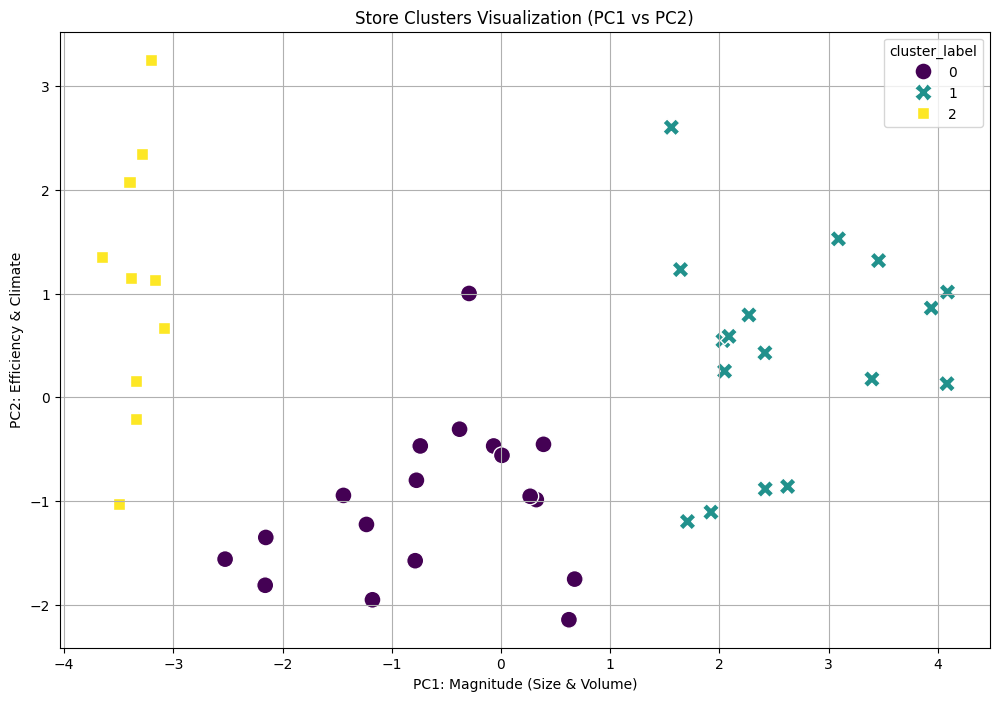

Cluster Business Profiles:
               Store_Count  Avg_Weekly_Sales   Avg_Size  Sales_Per_SqFt  \
cluster_label                                                             
0                       18          12372.20  119013.94            0.11   
1                       17          22871.99  195622.00            0.12   
2                       10           8319.08   39511.70            0.21   

               Avg_CPI  Avg_Unemployment Most_Common_Type  
cluster_label                                              
0               161.79              7.86                B  
1               176.80              7.94                A  
2               180.40              8.34                C  


In [31]:

# 1. FIT FINAL MODEL (k=3)
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)

# We predict on the PCA data (The "Math" version)
# But we store labels in BOTH the PCA df and the Original Profile df (The "Human" version)
df_pca['cluster_label'] = kmeans_final.fit_predict(df_pca)
store_profile['cluster_label'] = df_pca['cluster_label'].values

# 2. VISUALIZE (PC1 vs PC2)
# PC1 = Magnitude (Size/Sales) | PC2 = Efficiency/Climate
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_pca, 
    x='PC1', 
    y='PC2', 
    hue='cluster_label', 
    palette='viridis', 
    s=150, 
    style='cluster_label'
)
plt.title('Store Clusters Visualization (PC1 vs PC2)')
plt.xlabel('PC1: Magnitude (Size & Volume)')
plt.ylabel('PC2: Efficiency & Climate')
plt.grid(True)
plt.show()

# 3. CREATE BUSINESS PROFILE (The "Identity Card")
# We group by Cluster ID and calculate real-world averages
cluster_summary = store_profile.groupby('cluster_label').agg({
    'store': 'count',                 # How many stores in this group?
    'avg_weekly_sales': 'mean',       # Revenue
    'size': 'mean',                   # Physical Size
    'sales_per_sqft': 'mean',         # Efficiency
    'avg_cpi': 'mean',                # Economic Status
    'avg_unemployment': 'mean',       # Economic Health
    'type': lambda x: x.mode()[0]     # Most common Type (A, B, or C)
}).round(2)

# Rename for clarity
cluster_summary.columns = [
    'Store_Count', 'Avg_Weekly_Sales', 'Avg_Size', 
    'Sales_Per_SqFt', 'Avg_CPI', 'Avg_Unemployment', 'Most_Common_Type'
]

print("Cluster Business Profiles:")
print(cluster_summary)

# Save the final labeled data for the next notebook (Forecasting)
store_profile.to_csv('../data/preprocessed_for_models/Store_Profiles_With_Clusters.csv', index=False)